In [80]:
import sys
!{sys.executable} -m pip install -U langgraph langchain langchain-openai python-dotenv

Defaulting to user installation because normal site-packages is not writeable


In [81]:
from __future__ import annotations

import operator
from typing import Annotated, List, TypedDict

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [82]:
from dotenv import load_dotenv
load_dotenv()

True

In [83]:
class Task(BaseModel):
    id:int
    title:str
    brief:str=Field(...,description="What to cover?")

In [84]:
class Plan(BaseModel):
    blog_title:str
    tasks:List[Task]

In [85]:
class State(TypedDict):
    topic:str
    plan:Plan
    sections: Annotated[List[str],operator.add]
    final:str

In [86]:
llm=ChatOpenAI(model="gpt-4.1-mini")

In [87]:
def orchestrator(state:State)->dict:
    plan=llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=("Create a blog plan with 5-7 sections on following topic")
            ),
            HumanMessage(content=f"Topic: {state['topic']}")
        ]
    )
    return {"plan":plan}

In [88]:
#check how many task are in plan object

def fanout(state:State):
    return [Send("worker",{"task":task,"topic":state['topic'],"plan":state["plan"]})
        for task in state["plan"].tasks]

In [89]:
def worker(payLoad:dict)->dict:
    task=payLoad["task"]
    topic=payLoad["topic"]
    plan=payLoad["plan"]

    blog_title=plan.blog_title

    section_md=llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog:{blog_title}\n"
                    f"Topic:{topic}\n\n"
                    f"Section:{task.title}\n"
                    f"Brief:{task.brief}\n\n"
                    "Return only section content in markdown"
                
                )
                    ),
        ]
    ).content.strip()
    return {"sections":[section_md]}

In [90]:
from pathlib import Path
def reducer(state:State)->dict:
    title=state['plan'].blog_title
    body="\n\n".join(state["sections"]).strip()
    final_md=f"# {title}\n\n{body}\n"

    file_name=title.lower().replace(" ","_")+".md"
    output_path=Path(file_name)
    output_path.write_text(final_md,encoding="utf-8")
    return {"final":final_md}

In [91]:
g=StateGraph(State)
g.add_node("orchestrator",orchestrator)
g.add_node("worker",worker)
g.add_node("reducer",reducer)

In [92]:
g.add_edge(START,"orchestrator")
g.add_conditional_edges("orchestrator",fanout,["worker"])
g.add_edge("worker","reducer")
g.add_edge("reducer",END)

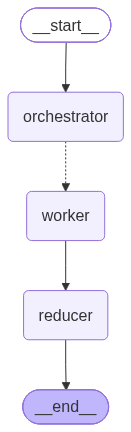

In [93]:
app=g.compile()
app

In [94]:
out=app.invoke({"topic":"Write a blog on Self Attention","sections":[]})

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}